# Project Title: Fast Food Consumption & Health Impact Analysis
##  Project Description

- This project analyzes the impact of fast food consumption on an individual's overall health using data science and machine learning techniques.
- The dataset contains various features such as age, gender, BMI, eating habits, and health indicators.
-  The main goal is to understand how lifestyle factors, especially fast food intake, influence health scores and to build predictive models.

# Objectives
- To explore and understand the dataset using Exploratory Data Analysis (EDA)
- To identify relationships between fast food consumption and health
- To build a regression model to predict overall health score
- To classify individuals into health categories (Low, Medium, High)
- To compare different machine learning models for classification

### Import  Libraries

In [1]:
import pandas as pd 
import numpy as nb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

###  Load Dataset

In [2]:
df = pd.read_csv("fast_food_consumption_health_impact_dataset.csv")
df.head(10)

,Age,Gender,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Digestive_Issues,Doctor_Visits_Per_Year,Overall_Health_Score
0,56,Male,1,3153,28.4,4.5,7.8,9,No,7,5
1,46,Male,12,1748,22.8,9.6,6.7,2,No,4,3
2,32,Female,8,3020,21.5,4.0,7.4,2,Yes,7,4
3,25,Female,6,2621,26.8,8.4,6.1,6,No,7,8
4,38,Female,14,2260,18.1,1.9,7.7,7,No,5,4
5,56,Female,7,3261,18.1,6.7,8.1,7,No,1,9
6,36,Male,14,1901,21.7,9.8,4.7,9,No,7,9
7,40,Male,10,2983,18.6,1.0,8.2,6,Yes,10,6
8,28,Female,1,1837,19.8,0.1,6.7,8,Yes,5,2
9,28,Male,6,2246,23.8,4.3,8.2,6,No,5,7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               800 non-null    int64  
 1   Gender                            800 non-null    object 
 2   Fast_Food_Meals_Per_Week          800 non-null    int64  
 3   Average_Daily_Calories            800 non-null    int64  
 4   BMI                               800 non-null    float64
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64
 6   Sleep_Hours_Per_Day               800 non-null    float64
 7   Energy_Level_Score                800 non-null    int64  
 8   Digestive_Issues                  800 non-null    object 
 9   Doctor_Visits_Per_Year            800 non-null    int64  
 10  Overall_Health_Score              800 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 68.9+ KB


In [4]:
df.describe(include = "all")

,Age,Gender,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Digestive_Issues,Doctor_Visits_Per_Year,Overall_Health_Score
count,800.000000,800,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800,800.000000,800.000000
unique,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
freq,NaN,385,NaN,NaN,NaN,NaN,NaN,NaN,497,NaN,NaN
mean,38.802500,NaN,6.818750,2554.728750,26.43900,4.938000,6.472875,4.903750,NaN,5.648750,4.922500
std,12.055919,NaN,4.329183,551.078974,4.94144,2.860272,1.429232,2.587538,NaN,3.467045,2.681974
min,18.000000,NaN,0.000000,1600.000000,18.00000,0.000000,4.000000,1.000000,NaN,0.000000,1.000000
25%,29.000000,NaN,3.000000,2084.750000,22.50000,2.400000,5.200000,3.000000,NaN,3.000000,3.000000
50%,40.000000,NaN,7.000000,2540.500000,26.40000,4.900000,6.500000,5.000000,NaN,6.000000,5.000000
75%,49.000000,NaN,11.000000,3049.000000,30.62500,7.400000,7.700000,7.000000,NaN,9.000000,7.000000


In [5]:
df.describe(include="O")

,Gender,Digestive_Issues
count,800,800
unique,3,2
top,Male,No
freq,385,497


In [6]:
df.isnull().sum()

Age                                 0
Gender                              0
Fast_Food_Meals_Per_Week            0
Average_Daily_Calories              0
BMI                                 0
Physical_Activity_Hours_Per_Week    0
Sleep_Hours_Per_Day                 0
Energy_Level_Score                  0
Digestive_Issues                    0
Doctor_Visits_Per_Year              0
Overall_Health_Score                0
dtype: int64

In [7]:
df['Digestive_Issues'].unique()

array(['No', 'Yes'], dtype=object)

### Data Preprocessing

In [8]:
# Handle missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

In [9]:
# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

### Basic Dataset Overview

### 1. Histogram (Distribution of Health Score)

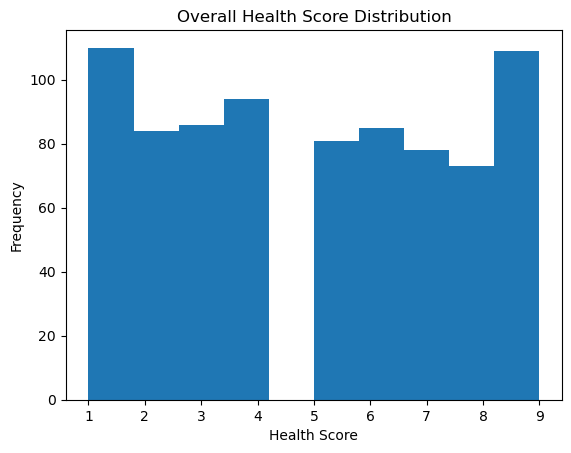

In [10]:
plt.figure()
plt.hist(df['Overall_Health_Score'])
plt.title("Overall Health Score Distribution")
plt.xlabel("Health Score")
plt.ylabel("Frequency")
plt.show()

### 2.  Relationship Between Features
- Fast Food vs Health Score

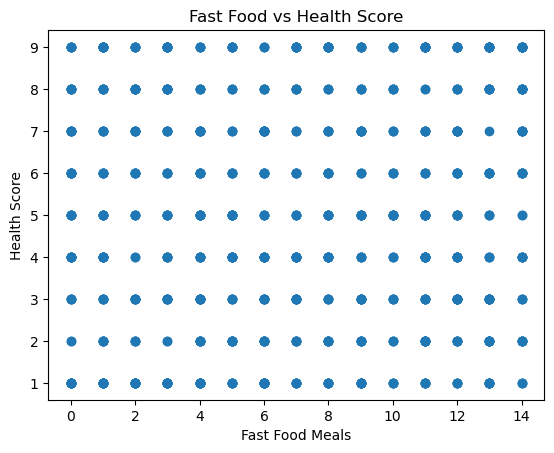

In [11]:
plt.figure()
plt.scatter(df['Fast_Food_Meals_Per_Week'], df['Overall_Health_Score'])
plt.title("Fast Food vs Health Score")
plt.xlabel("Fast Food Meals")
plt.ylabel("Health Score")
plt.show()

### 3. BMI vs Health Score

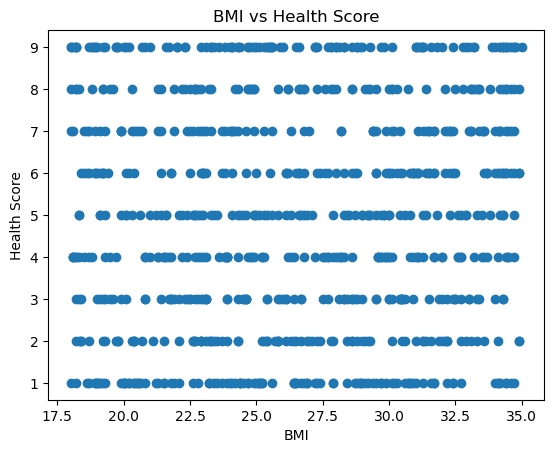

In [12]:
plt.figure()
plt.scatter(df['BMI'], df['Overall_Health_Score'])
plt.title("BMI vs Health Score")
plt.xlabel("BMI")
plt.ylabel("Health Score")
plt.show()

### 4. Box Plot (Outliers)

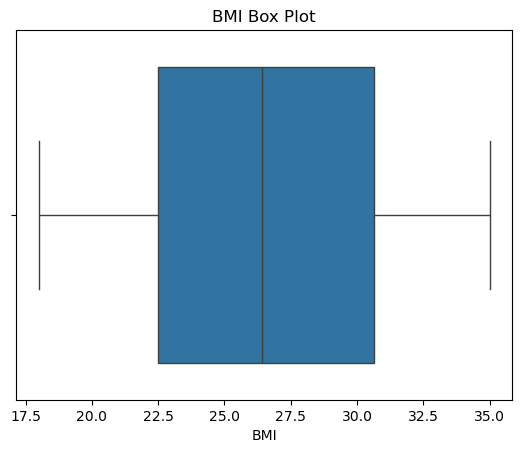

In [13]:
plt.figure()
sns.boxplot(x=df['BMI'])
plt.title("BMI Box Plot")
plt.show()

### 5. Correlation Heatmap (VERY IMPORTANT)
- Shows which features strongly affect health

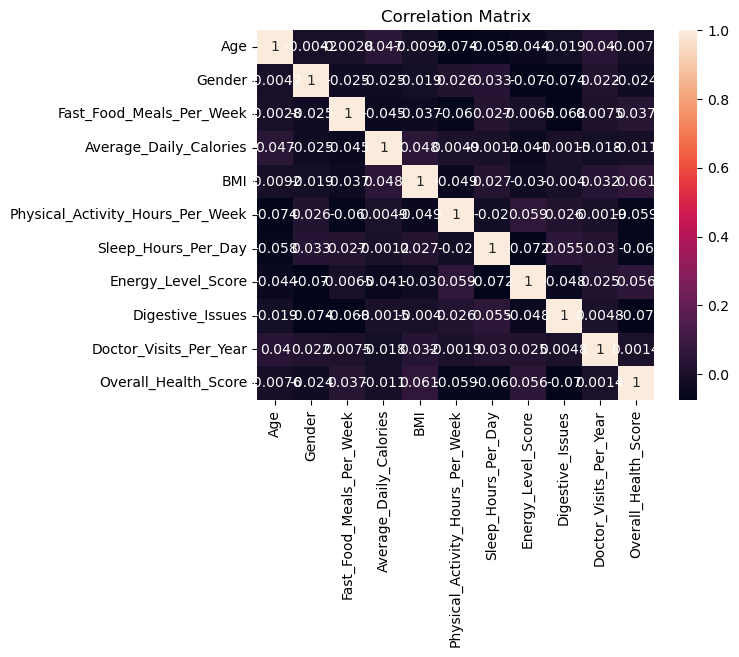

In [14]:
plt.figure()
corr = df.corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

### Histogram for Age

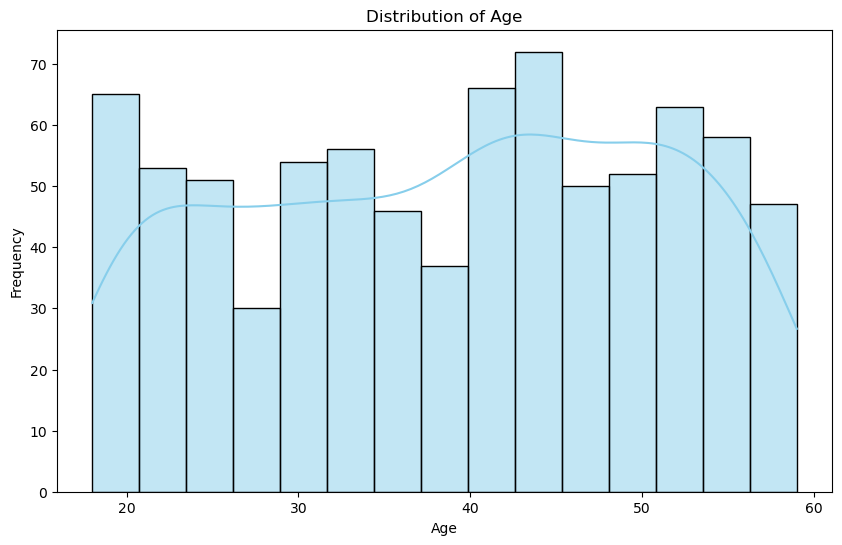

In [15]:
# Set the size of the figures for better readability
plt.figure(figsize=(10, 6))

sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Gender Distribution
-  Count plot (pie chart style) using countplot as a substitute

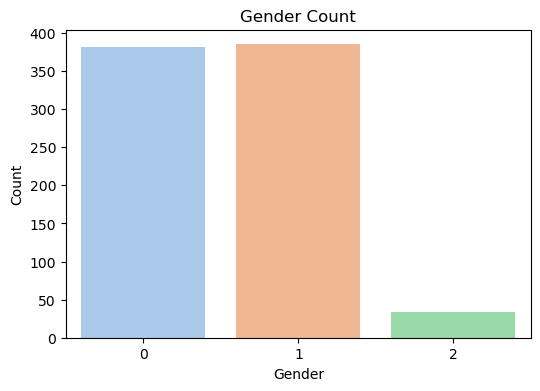

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Count')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Grouped Bar Plot: Average doctor's visits by Gender

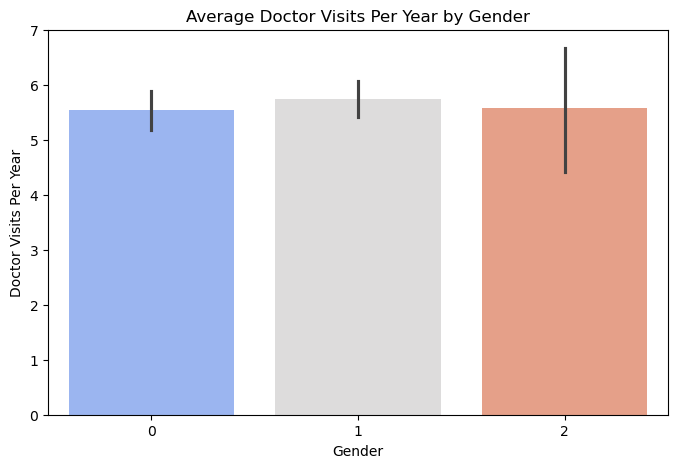

In [17]:

plt.figure(figsize=(8, 5))
sns.barplot(x='Gender', y='Doctor_Visits_Per_Year', data=df, palette='coolwarm')
plt.title('Average Doctor Visits Per Year by Gender')
plt.xlabel('Gender')
plt.ylabel('Doctor Visits Per Year')
plt.show()

In [18]:
print(df.columns.tolist())

['Age', 'Gender', 'Fast_Food_Meals_Per_Week', 'Average_Daily_Calories', 'BMI', 'Physical_Activity_Hours_Per_Week', 'Sleep_Hours_Per_Day', 'Energy_Level_Score', 'Digestive_Issues', 'Doctor_Visits_Per_Year', 'Overall_Health_Score']


In [19]:
X = df.drop('Overall_Health_Score', axis=1)
y = df['Overall_Health_Score']

In [20]:
print(df['Overall_Health_Score'].dtype)
print(df['Overall_Health_Score'].unique())

int64
[5 3 4 8 9 6 2 7 1]


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred = lr.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 6.835537174293023


# CLASSIFICATION MODELS

### Health score converted into categories:
- Low (0–40)
-  Medium (41–70)
-  High (71–100)

In [24]:
df['Health_Category'] = pd.cut(
    df['Overall_Health_Score'],
    bins=[0, 40, 70, 100],
    labels=['Low', 'Medium', 'High']
)

### Define Features and Target

##### i.  Change target column as per dataset

In [25]:
X = df.drop(['Overall_Health_Score', 'Health_Category'], axis=1)
y = df['Health_Category']

##### ii. Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
df['Health_Category'] = pd.qcut(
    df['Overall_Health_Score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

##### iii.Feature Scaling

In [29]:
X = df.drop(['Overall_Health_Score', 'Health_Category'], axis=1)
y = df['Health_Category']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [30]:
print(y_train.value_counts())

Health_Category
Low       225
High      212
Medium    203
Name: count, dtype: int64


#  MODELS

### Logistic Regression

In [31]:
from sklearn.metrics import accuracy_score

log = LogisticRegression()
log.fit(X_train, y_train)

y_pred = log.predict(X_test)
log_acc = accuracy_score(y_test, y_pred)

print("Logistic Accuracy:", log_acc)

Logistic Accuracy: 0.29375


### K-Nearest Neighbors (KNN)

In [32]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.35625


### Naive Bayes

In [33]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, y_pred)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.3375


### Decision Tree

In [34]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.3125


### Evaluation metric :  Accuracy Score

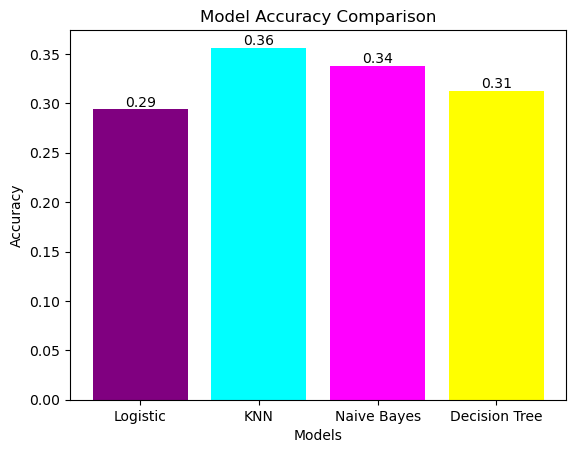

In [35]:
import matplotlib.pyplot as plt

models = ['Logistic', 'KNN', 'Naive Bayes', 'Decision Tree']
accuracy = [log_acc, knn_acc, nb_acc, dt_acc]

colors = ['purple', 'cyan', 'magenta', 'yellow']

plt.figure()
bars = plt.bar(models, accuracy, color=colors)

# Add accuracy values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             yval, 
             round(yval, 2),   # round to 2 decimals
             ha='center', 
             va='bottom')

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

### Compare Results

In [36]:
print("\nModel Comparison Done Successfully!")


Model Comparison Done Successfully!


### Model Comparison
- Compared performance of all classification models
- Visualized accuracy using bar chart
- Helps identify the best performing algorithm

### Conclusion
- This project demonstrates how data analysis and machine learning can be used to study real-world health problems.
- It provides insights into how lifestyle choices impact health and helps in predicting health conditions using different algorithms.